# Advance Matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
plt.style.use('dark_background')

## Colored Scatterplot

In [2]:
iris = pd.read_csv('https://drive.google.com/uc?id=13cR6Fc1QUx7P23JTsyh28dxlHUD9Qeti')
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [14]:
iris['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

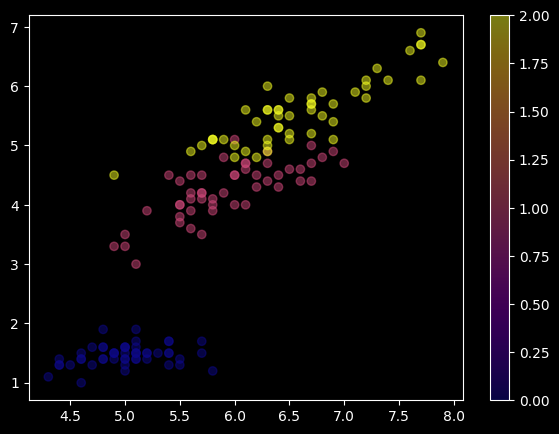

In [93]:
iris['Species'] = iris['Species'].replace({
    'Iris-setosa':0,
    'Iris-versicolor':1,
    'Iris-virginica':2
})
plt.figure(figsize=(7, 5))
plt.scatter(iris['SepalLengthCm'], iris['PetalLengthCm'], c=iris['Species'],cmap='plasma', alpha=0.5)

plt.colorbar()

In [18]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

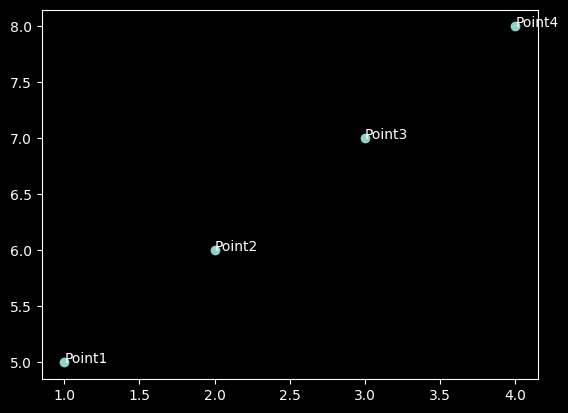

In [94]:
# Annotated
x = [1, 2, 3, 4]
y = [5, 6, 7, 8]
points = ['Point1', 'Point2', 'Point3', 'Point4']
plt.scatter(x, y)

for i in range(4):
    plt.text(x[i], y[i], points[i])
# plt.text(1, 5, '(1, 5)', fontdict={'size':10, 'color':'brown'})

plt.show()

In [44]:
batter = pd.read_csv('https://drive.google.com/uc?id=1bZT5Hd48jJKVp3Cf8PhNS__-E5IeY9bD')
batter.sample(5)

,batter,runs,avg,strike_rate
381,RJ Peterson,32,10.666667,100.000000
426,NJ Maddinson,20,6.666667,95.238095
1,S Dhawan,6244,34.882682,122.840842
176,RK Singh,251,20.916667,123.039216
386,RV Patel,31,15.500000,96.875000


In [61]:
batter = batter.sort_values('runs',ascending=False).head(50).sample(10)

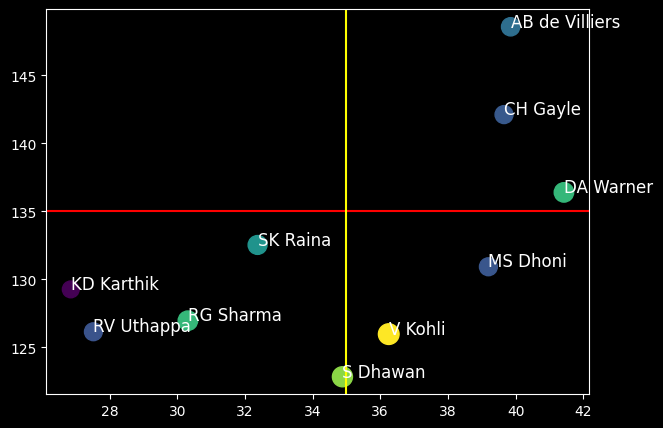

In [100]:
plt.figure(figsize=(7, 5))
plt.scatter(batter['avg'], batter['strike_rate'], s=batter['runs']/30, c=batter['runs'],cmap=None)

for i in range(batter.shape[0]):
    plt.text(batter['avg'][i], batter['strike_rate'][i], batter['batter'][i], fontdict={'size':12})

plt.axhline(135, color='red')
plt.axvline(35, color='yellow')


plt.show()


## Subplots

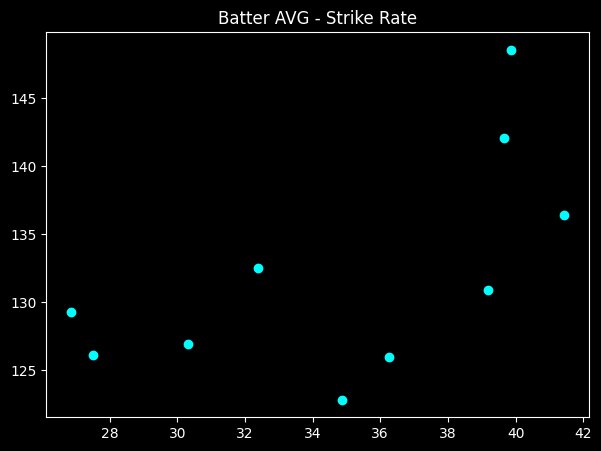

In [119]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(batter['avg'], batter['strike_rate'], color='cyan')
ax.set_title('Batter AVG - Strike Rate')

plt.show()

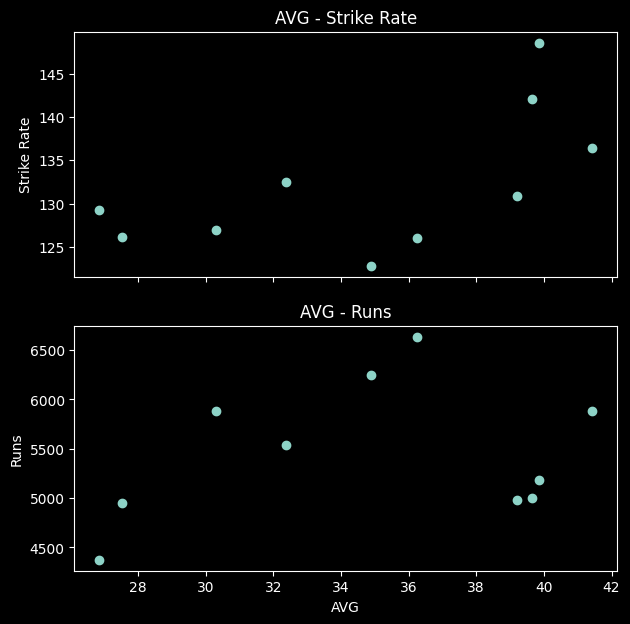

In [148]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(7, 7))
ax[0].scatter(batter['avg'], batter['strike_rate'])
ax[1].scatter(batter['avg'], batter['runs'])

ax[0].set_title('AVG - Strike Rate')
ax[1].set_title('AVG - Runs')

ax[1].set_xlabel('AVG')
ax[0].set_ylabel('Strike Rate')
ax[1].set_ylabel('Runs')

plt.show()

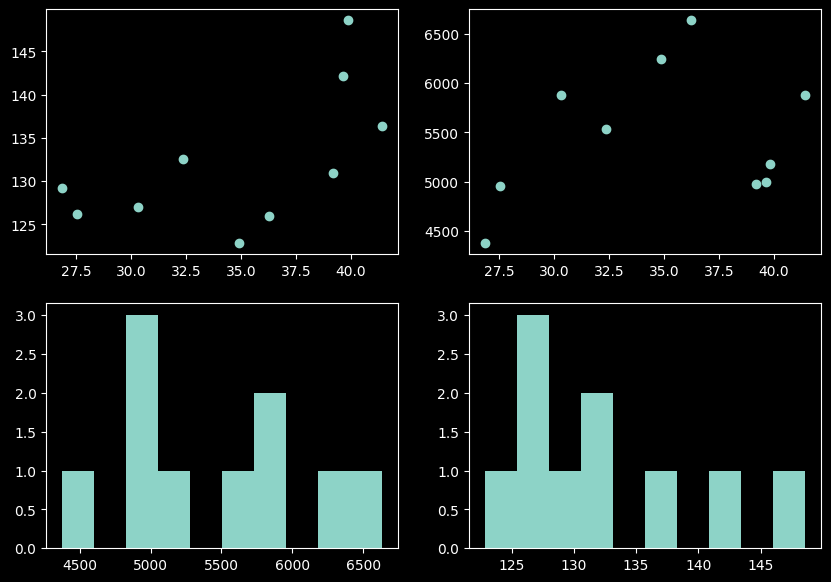

In [155]:
fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(batter['avg'], batter['strike_rate'])

ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(batter['avg'], batter['runs'])

ax3 = fig.add_subplot(2, 2, 3)
ax3.hist(batter['runs'])

ax4 = fig.add_subplot(2, 2, 4)
ax4.hist(batter['strike_rate'])

plt.show()

In [ ]:
## 3D Scatter Plot